In [1]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit import QuantumCircuit, transpile, QuantumRegister,ClassicalRegister
from qiskit.circuit.library import StatePreparation, PauliGate
import numpy as np 
A = np.array([[ 1.5 , -0.25,  0.  ,  0.  ],
              [-0.25,  1.5 , -0.25,  0.  ],
              [ 0.  , -0.25,  1.5 , -0.25],
              [ 0.  ,  0.  , -0.25,  1.5 ]])

# a = 0.25
# b = 0.75

# # matrix to be decomposed
# A = np.array(
#     [[a,  0, 0,  b],
#      [0, -a, b,  0],
#      [0,  b, a,  0],
#      [b,  0, 0, -a]]
# )

pauli_op = SparsePauliOp.from_operator(A)
pauli_op

SparsePauliOp(['II', 'IX', 'XX', 'YY'],
              coeffs=[ 1.5  +0.j, -0.25 +0.j, -0.125+0.j, -0.125+0.j])

In [2]:
# convert |0>^k -----> Sum( c_i|i>) 
# U∣0⟩=k∑​ak​∣k⟩
n_ancilla = int(np.ceil(np.log2(len(pauli_op.coeffs))))
n_reg = int(np.log2(len(A)))
amps = np.sqrt(np.abs(pauli_op.coeffs)/np.linalg.norm(pauli_op.coeffs,ord=1))
padded_amps = np.zeros(2**n_ancilla)
padded_amps[:len(amps)] = amps

In [ ]:
 #np.array([1,0,0,0])

In [ ]:
ψ = "0"*n_reg
ctrl_reg = QuantumRegister(n_ancilla,name='ctrl')
encode_reg = QuantumRegister(n_reg,name='q')
cl_red = ClassicalRegister(n_ancilla)

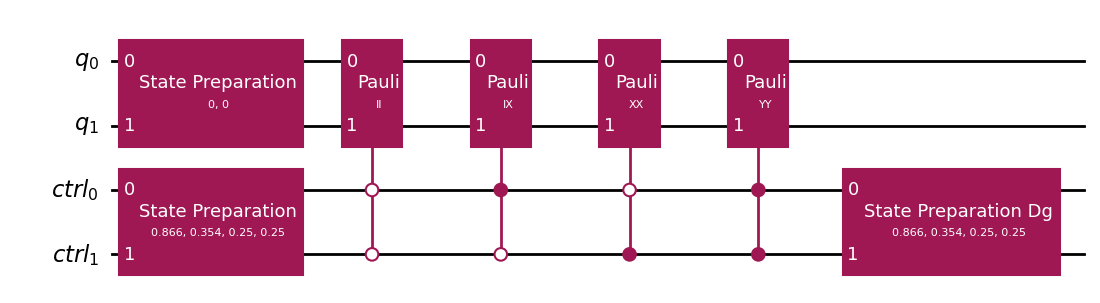

In [ ]:
qc  = QuantumCircuit(encode_reg,ctrl_reg,)
qc.prepare_state(ψ,encode_reg)
qc.prepare_state(padded_amps,ctrl_reg)

for index, pauli in enumerate(pauli_op.paulis):
    intstr = np.binary_repr(index,n_ancilla)
    control_pauli_k = pauli.to_instruction().control(num_ctrl_qubits=n_ancilla,ctrl_state=intstr)
    qc.append(control_pauli_k,ctrl_reg[:] + encode_reg[::])

qc.prepare_state(padded_amps,ctrl_reg).inverse()

# qc.measure(qc.qubits[:n_ancilla],qc.clbits)
qc.draw("mpl")

In [51]:
U = Operator(qc).to_matrix()
print(np.real(np.round(U[:4,:4] * np.linalg.norm(pauli_op.coeffs,ord=1),2)))

[[ 1.5   0.25  0.   -0.  ]
 [ 0.25  1.5   0.25  0.  ]
 [ 0.    0.25  1.5   0.25]
 [-0.    0.    0.25  1.5 ]]


In [ ]:
def selection_matrix(pauli_op : SparsePauliOp):
    dim = len[pauli_op.coeffs]
    select_matrix = None
    for i in range(dim):
        u_k = pauli_op.paulis[i].to_matrix()
        ket_i = Statevector.from_int(i, dim).data
        outer_product = np.outer(ket_i,ket_i.conj())

        if not select_matrix:
            select_matrix = np.kron(outer_product,u_k)
        else:
            select_matrix = select_matrix + np.kron(outer_product,u_k)
    return select_matrix
